# Grid-based Boomerang — quick sampling demo

Sample from `make_gaussian`, `make_banana`, and `make_gaussian_mixture` (from `sazz.models.math_targets`, imported read-only) using the new `GridBoomerangSampler` (`sazz/gpu_friendly/samplers/grid_boomerang.py`), which uses the Andral & Kamatani (2024) grid-based piecewise-constant upper bound instead of Brent/PLI.

This notebook only exercises the new `sazz/gpu_friendly/` tree — nothing in `sazz/samplers/` or `sazz/models/` is modified. The analytic `math_targets.py` closures are pure functions of `beta` (no detaching), so they compose directly with the grid sampler's `torch.func.grad`/`vmap`/`jvp`-based bound construction without any adapter.

In [ ]:
import os
from pathlib import Path

import math
import numpy as np
import torch
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    os.chdir("..")

from sazz.models.math_targets import make_gaussian, make_banana, make_gaussian_mixture
from sazz.gpu_friendly.samplers.grid_boomerang import GridBoomerangSampler

In [ ]:
def run_grid_boomerang(target, N=5000, refresh_rate=1.0, n_segments=20,
                        grid_t_max_init=math.pi / 4, dtype=torch.float64):
    """Build a GridBoomerangSampler for `target` and run it for N skeleton points."""
    sampler = GridBoomerangSampler(
        grad_target=target.grad_target,
        D=target.D,
        refresh_rate=refresh_rate,
        grid_t_max_init=grid_t_max_init,
        n_segments=n_segments,
        dtype=dtype,
    )
    sampler.preprocess(x_ref=target.x_ref, Sigma_inv=target.Sigma_inv)
    result = sampler.sample(N=N, diagnostics=True)
    result["sampler"] = sampler
    return result

def plot_marginals(target, result, max_coords=4, bins=60, burnin_frac=0.2):
    """Histogram of each coordinate vs the analytic marginal PDF, plus the
    adaptive grid_t_max trajectory over the run."""
    coords = list(target.marginal_grids.keys())[:max_coords]
    positions = result["positions"].numpy()
    n = positions.shape[0]
    burn = int(burnin_frac * n)
    samples = positions[burn:]

    fig, axes = plt.subplots(1, len(coords) + 1, figsize=(3.2 * (len(coords) + 1), 3))

    for i, c in enumerate(coords):
        ax = axes[i]
        info = target.marginal_grids[c]
        ax.hist(samples[:, c], bins=bins, density=True, alpha=0.5, label="grid boomerang")
        ax.plot(info["grid"], info["pdf"], "k--", lw=1.5, label="analytic")
        ax.set_title(info["label"])
        if i == 0:
            ax.legend(fontsize=8)

    ax = axes[-1]
    ax.plot(result["grid_t_max_log"])
    ax.set_title("adaptive grid_t_max")
    ax.set_xlabel("iteration")

    fig.tight_layout()
    plt.show()

    print(f"bound_violations: {result['bound_violations']}")
    print(f"gradient_evals: {result['gradient_evals']} "
          f"({result['gradient_evals'] / n:.1f} / skeleton point)")

## 0. Gaussian (diagonal)

The reference measure equals the target, so the excess gradient is identically zero. The grid Boomerang should report **zero bounces** (and, correspondingly, `bound_violations == 0` since the rate is exactly zero everywhere).

In [ ]:
target_gauss = make_gaussian(D=5, cov="diagonal")
print(f"Target: {target_gauss.name}  D={target_gauss.D}")
result_gauss = run_grid_boomerang(target_gauss, N=10000)

Target: gaussian_diagonal_D5  D=5


GridBoomerang: 100%|██████████| 10000/10000 [00:09<00:00, 1083.84skel/s, t=9942.802 t_max=6.0995 viol=0]



=== GridBoomerang Diagnostics ===
Total gradient evals  : 214305
Grad evals / skeleton : 21.4
Accepted bounces      : 0
Bound violations      : 0

=== Event breakdown ===
  no_event  : 10205 events, mean horizon=0.9748
  refresh   :  9999 events, mean horizon=0.0000

Mean wall-sec / iter : 0.000440
Total wall-sec       : 8.90

Simulation time reached: 9942.8015


GridBoomerang: 100%|██████████| 10000/10000 [00:08<00:00, 1167.87skel/s, t=10155.768 t_max=6.6049 viol=0]


=== GridBoomerang Diagnostics ===
Total gradient evals  : 214473
Grad evals / skeleton : 21.4
Accepted bounces      : 0
Bound violations      : 0

=== Event breakdown ===
  no_event  : 10213 events, mean horizon=0.9950
  refresh   :  9999 events, mean horizon=0.0000

Mean wall-sec / iter : 0.000408
Total wall-sec       : 8.24

Simulation time reached: 10155.7675


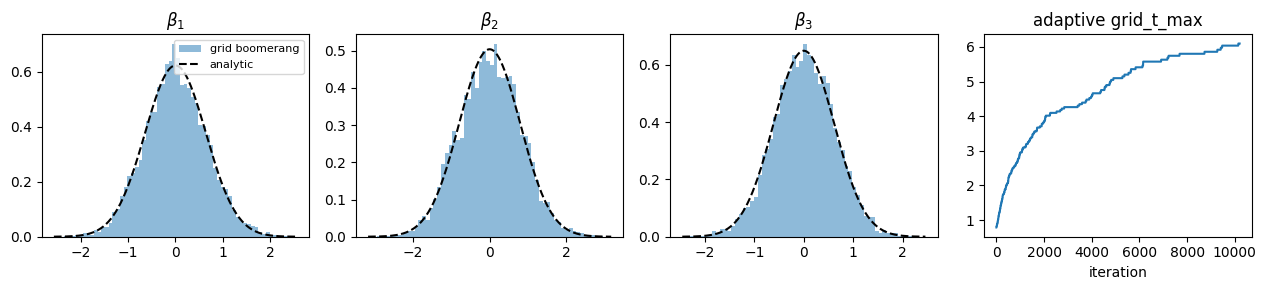

bound_violations: 0
gradient_evals: 214305 (21.4 / skeleton point)


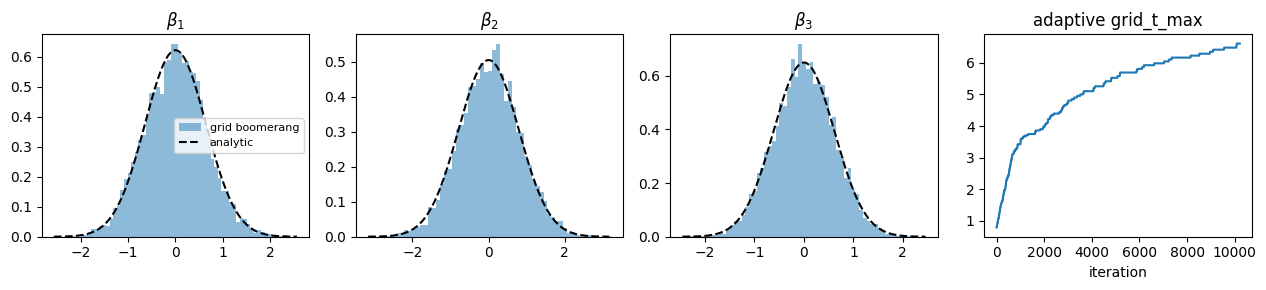

bound_violations: 0
gradient_evals: 214473 (21.4 / skeleton point)


In [ ]:
plot_marginals(target_gauss, result_gauss, max_coords=3)

## 1. Gaussian (non-diagonal)

A dense `Sigma_inv` still matching the target exactly — same zero-bounce expectation, but exercises the full-matrix path in `preprocess`/`grad_U_excess`/`reflect_velocity` instead of the diagonal shortcut.

In [ ]:
target_gauss_dense = make_gaussian(D=5, cov="random")
print(f"Target: {target_gauss_dense.name}  D={target_gauss_dense.D}")
print(f"Sigma_inv is dense: {target_gauss_dense.Sigma_inv.ndim == 2}")
result_gauss_dense = run_grid_boomerang(target_gauss_dense, N=10000)

In [ ]:
plot_marginals(target_gauss_dense, result_gauss_dense, max_coords=3)

## 2. Banana (Rosenbrock)

Non-Gaussian, curved geometry — the reference measure is only a rough match, so the excess gradient (and hence the rate) is genuinely non-trivial. Good stress test for the grid bound's tangent construction and the bound-violation safety net.

In [ ]:
target_banana = make_banana(a=1.0, scale=2.0)
print(f"Target: {target_banana.name}  D={target_banana.D}")
result_banana = run_grid_boomerang(target_banana, N=10000)

In [ ]:
plot_marginals(target_banana, result_banana)

# 2-D joint scatter for the banana
positions = result_banana["positions"].numpy()
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(positions[:, 0], positions[:, 1], s=2, alpha=0.3)
ax.set_title("Banana — grid boomerang skeleton")
plt.show()

## 3. Gaussian mixture (bimodal)

Two well-separated modes — tests whether the grid sampler can cross the low-density valley, and whether the adaptive `grid_t_max` behaves sensibly when the rate's shape varies a lot across the space.

In [ ]:
target_mix = make_gaussian_mixture(D=1, preset="bimodal")
print(f"Target: {target_mix.name}  D={target_mix.D}")
result_mix = run_grid_boomerang(target_mix, N=10000, refresh_rate=2.0)

In [ ]:
plot_marginals(target_mix, result_mix, max_coords=1)